In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sn
import scipy as sc
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

In [ ]:
df = pd.read_csv("KC_housing_data.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [ ]:
pd.set_option('display.float_format' , '{:,.2f}'.format)

In [ ]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,"4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00"
mean,"551,962.99",3.40,2.16,"2,139.35","14,852.52",1.51,0.01,0.24,3.45,"1,827.27",312.08,"1,970.79",808.61
std,"563,834.70",0.91,0.78,963.21,"35,884.44",0.54,0.08,0.78,0.68,862.17,464.14,29.73,979.41
min,0.00,0.00,0.00,370.00,638.00,1.00,0.00,0.00,1.00,370.00,0.00,"1,900.00",0.00
25%,"322,875.00",3.00,1.75,"1,460.00","5,000.75",1.00,0.00,0.00,3.00,"1,190.00",0.00,"1,951.00",0.00
50%,"460,943.46",3.00,2.25,"1,980.00","7,683.00",1.50,0.00,0.00,3.00,"1,590.00",0.00,"1,976.00",0.00
75%,"654,962.50",4.00,2.50,"2,620.00","11,001.25",2.00,0.00,0.00,4.00,"2,300.00",610.00,"1,997.00","1,999.00"
max,"26,590,000.00",9.00,8.00,"13,540.00","1,074,218.00",3.50,1.00,4.00,5.00,"9,410.00","4,820.00","2,014.00","2,014.00"


In [ ]:
df.isnull().sum();

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes;

In [ ]:
(df["price"] <= 0).sum()

np.int64(49)

In [ ]:
df = df[df["price"] > 0]

In [ ]:
#calculate the IQR
Q1 =df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.7)
IQR = Q3 - Q1
#calculate lower and upper limits
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [ ]:
outliers = df[(df['price']<
lower) | (df["price"]> upper)]
print(outliers.shape)

(327, 18)


In [ ]:
df = df[(df['price'] >= lower) & 
(df['price'] <= upper)]

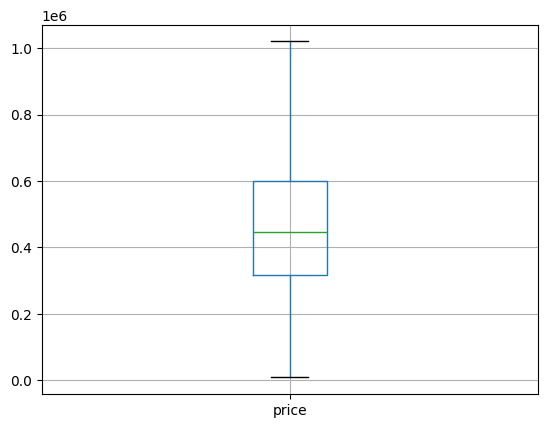

In [ ]:
df.boxplot(column="price")
plt.show()

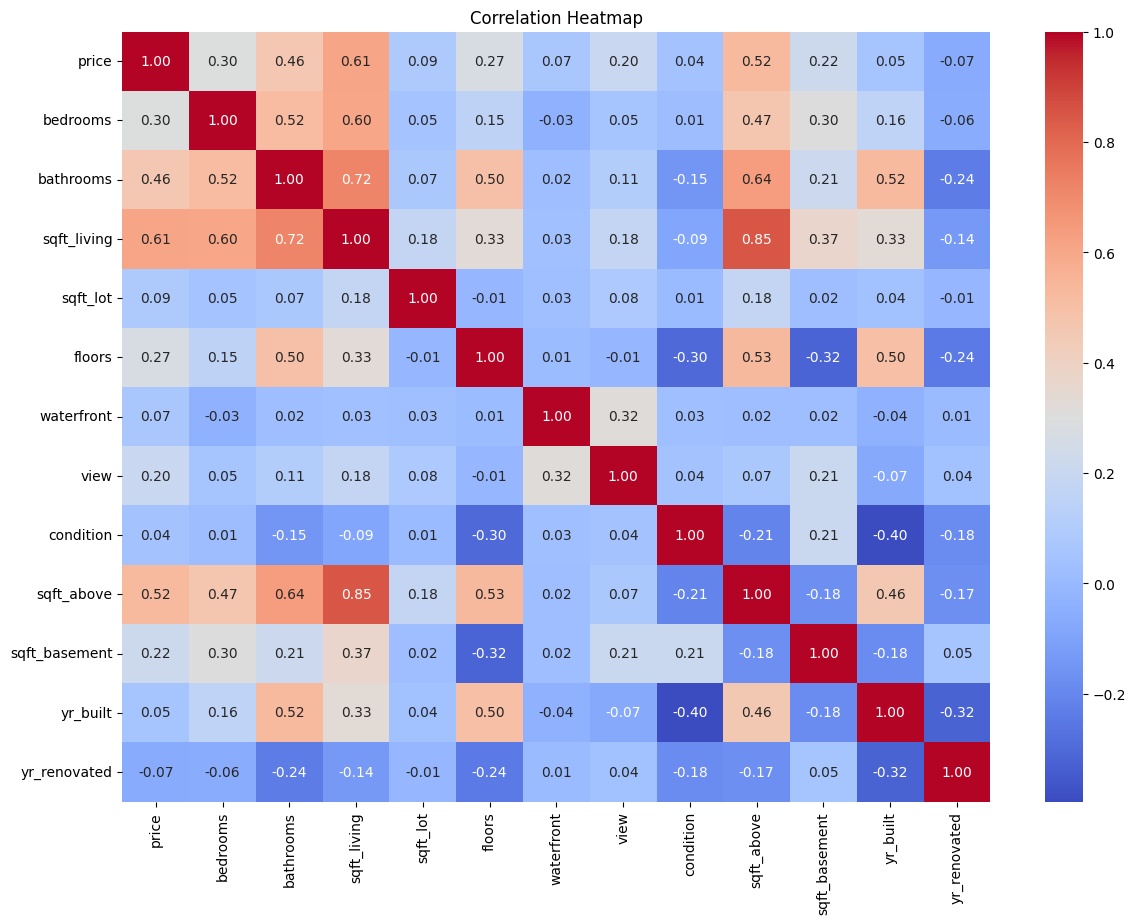

In [ ]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,      # Shows the numbers
    fmt=".2f",       # 2 decimal places
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df[["city", "country", "street", "statezip", "date"]].nunique()

city          44
country        1
street      4155
statezip      77
date          70
dtype: int64

In [17]:
df = df.drop(columns=["country", "street", "date"])

In [25]:
X = df.drop(columns=["price"])
y = df["price"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
cat_cols = ["city", "statezip"]

In [24]:
encoder = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)

X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [27]:
train_cat = pd.DataFrame(
    X_train_cat,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_train.index
)

test_cat = pd.DataFrame(
    X_test_cat,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_test.index
)

In [28]:
X_train = X_train.drop(columns=cat_cols)
X_test = X_test.drop(columns=cat_cols)

X_train = pd.concat([X_train, train_cat], axis=1)
X_test = pd.concat([X_test, test_cat], axis=1)

In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
y_train_pred = lr.predict(X_train_scaled)
y_test_pred = lr.predict(X_test_scaled)

In [32]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R²:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

Train R²: 0.7857368393175226
Test R²: 0.7804275917554511
MAE: 64502.92232885057
RMSE: 90531.54413771642


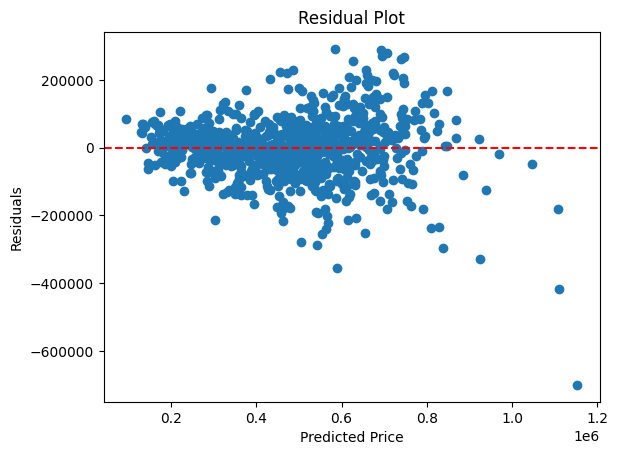

In [33]:
residuals = y_test - y_test_pred

plt.scatter(y_test_pred, residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

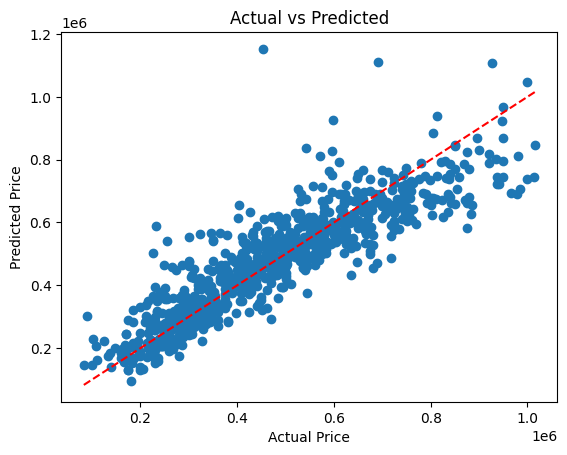

In [34]:
plt.scatter(y_test, y_test_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [37]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_
})

coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print(coef_df.head(10))

               Feature  Coefficient  Absolute_Coefficient
45        city_Seattle    74,709.42             74,709.42
8           sqft_above    61,032.65             61,032.65
2          sqft_living    60,500.29             60,500.29
14       city_Bellevue    40,880.91             40,880.91
41        city_Redmond    39,763.73             39,763.73
100  statezip_WA 98103    36,763.49             36,763.49
109  statezip_WA 98117    32,833.45             32,833.45
107  statezip_WA 98115    32,195.52             32,195.52
106  statezip_WA 98112    31,424.29             31,424.29
43      city_Sammamish    29,297.18             29,297.18


In [39]:
equation = f"Price = {lr.intercept_:.2f}"

for feature, coef in zip(X_train.columns, lr.coef_):
    equation += f" + ({coef:.2f} × {feature})"

print(equation)

Price = 475876.60 + (-7928.21 × bedrooms) + (15945.93 × bathrooms) + (60500.29 × sqft_living) + (7924.81 × sqft_lot) + (-11047.00 × floors) + (10314.01 × waterfront) + (17380.76 × view) + (14578.57 × condition) + (61032.65 × sqft_above) + (5167.03 × sqft_basement) + (-2694.50 × yr_built) + (2831.66 × yr_renovated) + (8324.05 × city_Auburn) + (3782.40 × city_Beaux Arts Village) + (40880.91 × city_Bellevue) + (3942.32 × city_Black Diamond) + (8596.32 × city_Bothell) + (18957.85 × city_Burien) + (5556.01 × city_Carnation) + (5237.56 × city_Clyde Hill) + (-292.67 × city_Covington) + (24002.17 × city_Des Moines) + (6434.16 × city_Duvall) + (1398.28 × city_Enumclaw) + (4829.01 × city_Fall City) + (3466.13 × city_Federal Way) + (25151.97 × city_Issaquah) + (11089.16 × city_Kenmore) + (5715.52 × city_Kent) + (28501.38 × city_Kirkland) + (10182.46 × city_Lake Forest Park) + (5000.86 × city_Maple Valley) + (-1997.09 × city_Medina) + (22217.51 × city_Mercer Island) + (927.52 × city_Milton) + (142